# 02 — Data Preprocessing
**Dataset:** Credit Card Fraud Detection — Kaggle (284,807 transaksione)

Qëllimi: Përgatisim të dhënat për trajnimin e modeleve duke kryer:
1. **Cleaning** — heqja e duplikatëve
2. **Scaling** — StandardScaler për Amount dhe Time
3. **Train/Test Split** — ndarja 80/20 e stratifikuar
4. **SMOTE** — balancimi i klasave në training set
5. **Feature Selection** — zgjedhja e featureve relevante
6. **Ruajtja** — export i të dhënave të parapërpunuara

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import os
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
pd.set_option('display.float_format', '{:.4f}'.format)

RANDOM_STATE = 42
print('Bibliotekat u ngarkuan me sukses!')

Bibliotekat u ngarkuan me sukses!


In [2]:
df = pd.read_csv('../data/creditcard.csv')
print(f'Dataset u ngarkua: {df.shape[0]:,} rreshta x {df.shape[1]} kolona')
df.head()

Dataset u ngarkua: 284,807 rreshta x 31 kolona


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0000,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,...,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0
1,0.0000,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,...,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0
2,1.0000,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,...,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0
3,1.0000,-0.9663,-0.1852,1.7930,-0.8633,-0.0103,1.2472,0.2376,0.3774,-1.3870,...,-0.1083,0.0053,-0.1903,-1.1756,0.6474,-0.2219,0.0627,0.0615,123.5000,0
4,2.0000,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,...,-0.0094,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,69.9900,0


## 1. Pastrimi i te Dhenave (Data Cleaning)

Nga EDA e meparshme dinim:
- **0 vlera null** — nuk kerkohet imputation
- **Duplikate te mundshme** — kontrollojme dhe heqim

Heqja e duplikateve eshte e rendesishme: rreshtat identike mund te shkaktojne data leakage dhe overfitting.

In [3]:
print('=' * 55)
print('KONTROLLI PARA PASTRIMIT')
print('=' * 55)
print(f'Rreshta totale     : {len(df):,}')
print(f'Vlera null (totale): {df.isnull().sum().sum()}')
print(f'Rreshta duplikate  : {df.duplicated().sum()}')
print(f'\nShperndarja e klasave:')
print(f'  Legjitime  (0): {(df["Class"] == 0).sum():,}')
print(f'  Mashtruese (1): {(df["Class"] == 1).sum():,}')

KONTROLLI PARA PASTRIMIT
Rreshta totale     : 284,807
Vlera null (totale): 0
Rreshta duplikate  : 1081

Shperndarja e klasave:
  Legjitime  (0): 284,315
  Mashtruese (1): 492


In [4]:
n_before = len(df)
df_clean = df.drop_duplicates().reset_index(drop=True)
n_after  = len(df_clean)
n_removed = n_before - n_after

print('=' * 55)
print('REZULTATI I PASTRIMIT')
print('=' * 55)
print(f'Rreshta para pastrimit : {n_before:,}')
print(f'Rreshta pas pastrimit  : {n_after:,}')
print(f'Duplikate te hequr     : {n_removed}')
print(f'\nShperndarja pas pastrimit:')
print(f'  Legjitime  (0): {(df_clean["Class"] == 0).sum():,}')
print(f'  Mashtruese (1): {(df_clean["Class"] == 1).sum():,}')

REZULTATI I PASTRIMIT
Rreshta para pastrimit : 284,807
Rreshta pas pastrimit  : 283,726
Duplikate te hequr     : 1081

Shperndarja pas pastrimit:
  Legjitime  (0): 283,253
  Mashtruese (1): 473


## 2. Skalimi i Featureve (Feature Scaling)

**Strategjia e skalimit:**
- **V1-V28**: jane tashme PCA-transformuar — **nuk skalojme**
- **Amount**: shperndarje e shtrember me vlera 0-25,691 — **StandardScaler**
- **Time**: sekonda 0-172,792 — **StandardScaler**

Pas skalimit: heqim kolonat origjinale `Amount` dhe `Time`.

In [5]:
scaler_amount = StandardScaler()
scaler_time   = StandardScaler()

df_scaled = df_clean.copy()
df_scaled['Amount_scaled'] = scaler_amount.fit_transform(df_clean[['Amount']])
df_scaled['Time_scaled']   = scaler_time.fit_transform(df_clean[['Time']])
df_scaled = df_scaled.drop(columns=['Amount', 'Time'])

# Rendit: V1-V28, Amount_scaled, Time_scaled, Class
feature_cols = [f'V{i}' for i in range(1, 29)] + ['Amount_scaled', 'Time_scaled']
df_scaled = df_scaled[feature_cols + ['Class']]

print('=== STATISTIKAT PAS SKALIMIT ===')
print(df_scaled[['Amount_scaled', 'Time_scaled']].describe().round(4))
print(f'\nTotale features: {len(feature_cols)} (V1-V28 + Amount_scaled + Time_scaled)')
print(f'Target kolona  : Class')
df_scaled.head()

=== STATISTIKAT PAS SKALIMIT ===
       Amount_scaled  Time_scaled
count    283726.0000  283726.0000
mean         -0.0000       0.0000
std           1.0000       1.0000
min          -0.3533      -1.9968
25%          -0.3310      -0.8552
50%          -0.2655      -0.2131
75%          -0.0438       0.9369
max         102.2476       1.6424

Totale features: 30 (V1-V28 + Amount_scaled + Time_scaled)
Target kolona  : Class


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Amount_scaled,Time_scaled,Class
0,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,0.0908,...,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,0.2442,-1.9968,0
1,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,-0.1670,...,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,-0.3426,-1.9968,0
2,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,0.2076,...,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,1.1589,-1.9968,0
3,-0.9663,-0.1852,1.7930,-0.8633,-0.0103,1.2472,0.2376,0.3774,-1.3870,-0.0550,...,0.0053,-0.1903,-1.1756,0.6474,-0.2219,0.0627,0.0615,0.1399,-1.9968,0
4,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,0.7531,...,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,-0.0738,-1.9968,0


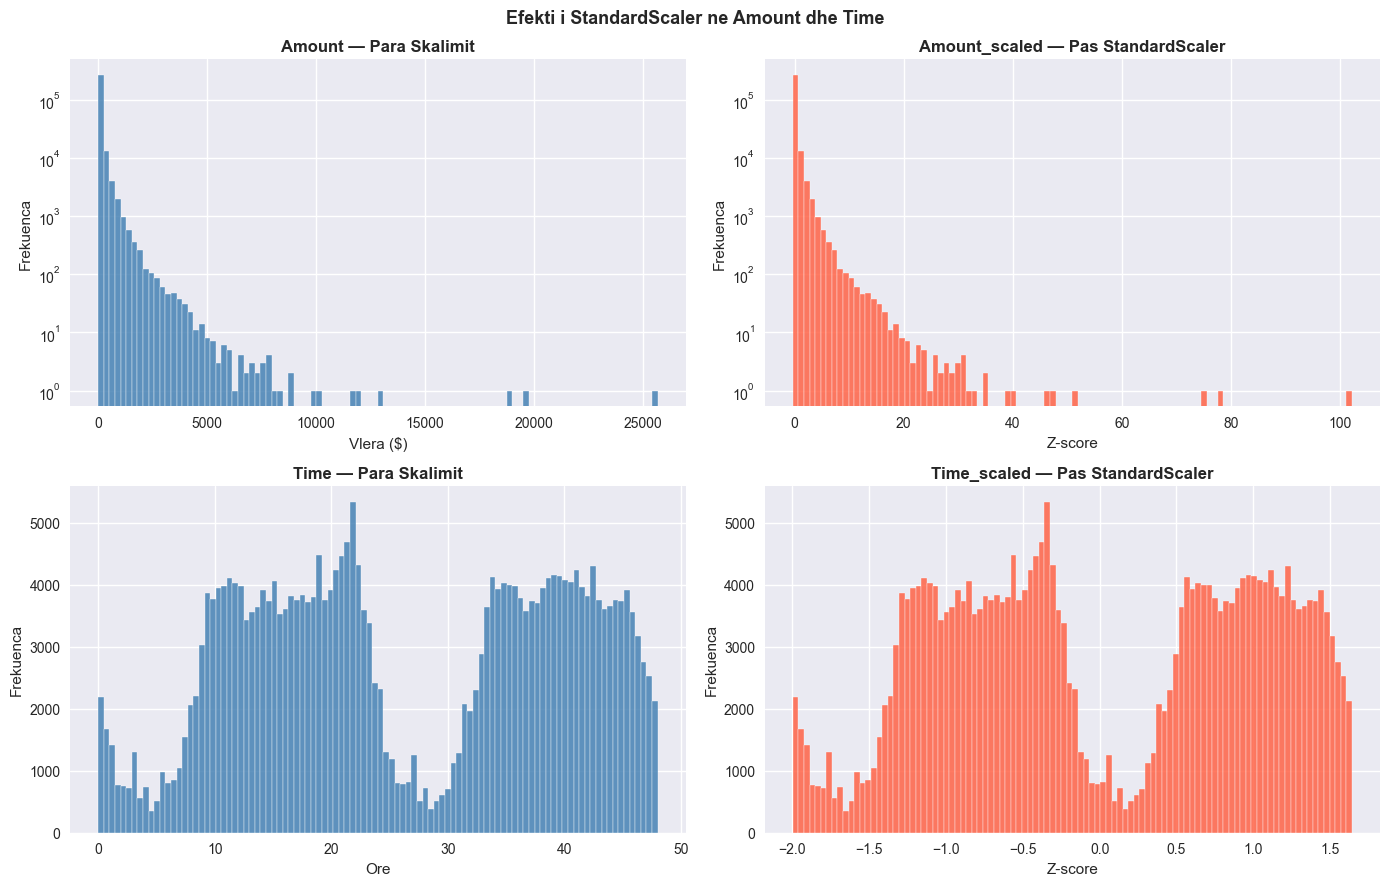

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0, 0].hist(df_clean['Amount'], bins=100, color='steelblue', alpha=0.85, edgecolor='white')
axes[0, 0].set_title('Amount — Para Skalimit', fontweight='bold')
axes[0, 0].set_xlabel('Vlera ($)')
axes[0, 0].set_ylabel('Frekuenca')
axes[0, 0].set_yscale('log')

axes[0, 1].hist(df_scaled['Amount_scaled'], bins=100, color='tomato', alpha=0.85, edgecolor='white')
axes[0, 1].set_title('Amount_scaled — Pas StandardScaler', fontweight='bold')
axes[0, 1].set_xlabel('Z-score')
axes[0, 1].set_ylabel('Frekuenca')
axes[0, 1].set_yscale('log')

axes[1, 0].hist(df_clean['Time'] / 3600, bins=100, color='steelblue', alpha=0.85, edgecolor='white')
axes[1, 0].set_title('Time — Para Skalimit', fontweight='bold')
axes[1, 0].set_xlabel('Ore')
axes[1, 0].set_ylabel('Frekuenca')

axes[1, 1].hist(df_scaled['Time_scaled'], bins=100, color='tomato', alpha=0.85, edgecolor='white')
axes[1, 1].set_title('Time_scaled — Pas StandardScaler', fontweight='bold')
axes[1, 1].set_xlabel('Z-score')
axes[1, 1].set_ylabel('Frekuenca')

plt.suptitle('Efekti i StandardScaler ne Amount dhe Time', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/scaling_effect.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Ndarja Train / Test

**Parametrat:**
- **80% training** / **20% testing** — raport standard per dataset-e te medha
- `stratify=y` — ruan proporcionin 99.83%/0.17% ne te dyja pjeset
- `random_state=42` — ripersetshem (reproducible)

**IMPORTANT:** SMOTE aplikohet **VETEM** ne training set — test set duhet te pasqyroje distribucionin real.

In [7]:
X = df_scaled[feature_cols].values
y = df_scaled['Class'].values

X_train_raw, X_test, y_train_raw, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print('=' * 55)
print('NDARJA TRAIN / TEST (80/20, stratified)')
print('=' * 55)
print(f'X_train: {X_train_raw.shape}   |  y_train: {y_train_raw.shape}')
print(f'X_test : {X_test.shape}    |  y_test : {y_test.shape}')

print(f'\nTraining set:')
for cls, cnt in zip(*np.unique(y_train_raw, return_counts=True)):
    print(f'  Klasa {cls}: {cnt:>7,}  ({cnt / len(y_train_raw) * 100:.3f}%)')

print(f'\nTest set:')
for cls, cnt in zip(*np.unique(y_test, return_counts=True)):
    print(f'  Klasa {cls}: {cnt:>7,}  ({cnt / len(y_test) * 100:.3f}%)')

NDARJA TRAIN / TEST (80/20, stratified)
X_train: (226980, 30)   |  y_train: (226980,)
X_test : (56746, 30)    |  y_test : (56746,)

Training set:
  Klasa 0: 226,602  (99.833%)
  Klasa 1:     378  (0.167%)

Test set:
  Klasa 0:  56,651  (99.833%)
  Klasa 1:      95  (0.167%)


## 4. Balancimi me SMOTE

**SMOTE** (Synthetic Minority Oversampling Technique) gjeneron shembuj sintetike te klases minoritare duke interpoluar mes shembujve ekzistues te afer (k-nearest neighbors).

**Pse SMOTE dhe jo random oversampling?**
- Random oversampling kopjon rreshtat ekzistues — overfitting
- SMOTE krijon shembuj *te rinj sintetike* — model me i pergjithshem

**`sampling_strategy=0.5`** — mashtruese = 50% e legjitimave (raporti 2:1 ne vend te 578:1)

In [8]:
smote = SMOTE(random_state=RANDOM_STATE, sampling_strategy=0.5)
X_train, y_train = smote.fit_resample(X_train_raw, y_train_raw)

print('=' * 55)
print('BALANCIMI ME SMOTE (sampling_strategy=0.5)')
print('=' * 55)

print(f'\nPara SMOTE — Training set:')
for cls, cnt in zip(*np.unique(y_train_raw, return_counts=True)):
    print(f'  Klasa {cls}: {cnt:>7,}  ({cnt / len(y_train_raw) * 100:.3f}%)')

print(f'\nPas SMOTE — Training set:')
for cls, cnt in zip(*np.unique(y_train, return_counts=True)):
    print(f'  Klasa {cls}: {cnt:>7,}  ({cnt / len(y_train) * 100:.3f}%)')

print(f'\nX_train final: {X_train.shape}')
print(f'y_train final: {y_train.shape}')
print(f'\nTest set nuk preket nga SMOTE — real-world distribution.')

BALANCIMI ME SMOTE (sampling_strategy=0.5)

Para SMOTE — Training set:
  Klasa 0: 226,602  (99.833%)
  Klasa 1:     378  (0.167%)

Pas SMOTE — Training set:
  Klasa 0: 226,602  (66.667%)
  Klasa 1: 113,301  (33.333%)

X_train final: (339903, 30)
y_train final: (339903,)

Test set nuk preket nga SMOTE — real-world distribution.


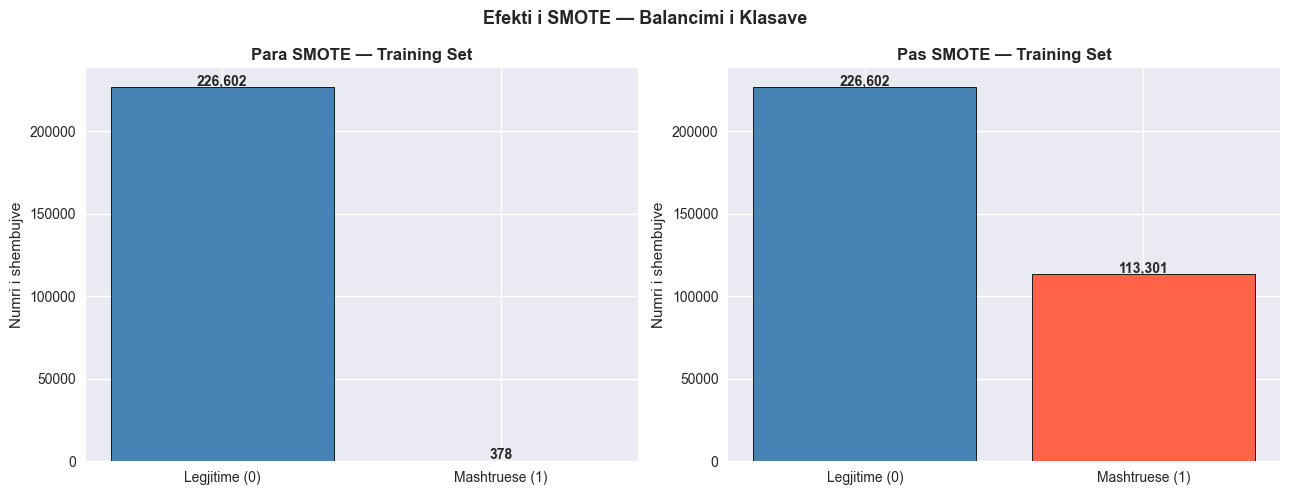

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

counts_before = np.unique(y_train_raw, return_counts=True)[1]
bars0 = axes[0].bar(['Legjitime (0)', 'Mashtruese (1)'], counts_before,
                    color=['steelblue', 'tomato'], edgecolor='black', linewidth=0.6)
axes[0].set_title('Para SMOTE — Training Set', fontweight='bold')
axes[0].set_ylabel('Numri i shembujve')
for bar, val in zip(bars0, counts_before):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 800,
                 f'{val:,}', ha='center', fontweight='bold', fontsize=10)

counts_after = np.unique(y_train, return_counts=True)[1]
bars1 = axes[1].bar(['Legjitime (0)', 'Mashtruese (1)'], counts_after,
                    color=['steelblue', 'tomato'], edgecolor='black', linewidth=0.6)
axes[1].set_title('Pas SMOTE — Training Set', fontweight='bold')
axes[1].set_ylabel('Numri i shembujve')
for bar, val in zip(bars1, counts_after):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 800,
                 f'{val:,}', ha='center', fontweight='bold', fontsize=10)

plt.suptitle('Efekti i SMOTE — Balancimi i Klasave', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/smote_effect.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Perzgjedhja e Featureve (Feature Selection)

Analizojme korrelacionin absolut te seciles feature me `Class` ne training set.

**Threshold:** |r| >= 0.02 — featurat nen kete vlere jane potencialisht jo-informative.

Shenm: V1-V28 jane tashme PCA-reduktuara, keshtu pritet shumica te kalojne filtrin.

In [10]:
# Llogarisim korrelacionin ne raw training set (para SMOTE)
train_df_raw = pd.DataFrame(X_train_raw, columns=feature_cols)
train_df_raw['Class'] = y_train_raw

corr_abs = train_df_raw.corr()['Class'].drop('Class').abs().sort_values(ascending=False)

THRESHOLD = 0.02
selected_features = corr_abs[corr_abs >= THRESHOLD].index.tolist()
dropped_features  = corr_abs[corr_abs < THRESHOLD].index.tolist()

print(f'=== FEATURE SELECTION (|korrelacion| >= {THRESHOLD}) ===')
print(f'Features totale      : {len(feature_cols)}')
print(f'Features te zgjedhura: {len(selected_features)}')
print(f'Features te hequra   : {len(dropped_features)}')

if dropped_features:
    print(f'\nFeatures nen threshold: {dropped_features}')

print(f'\nTop 15 features sipas korrelacionit me Class:')
print(corr_abs.head(15).round(4).to_string())

=== FEATURE SELECTION (|korrelacion| >= 0.02) ===
Features totale      : 30
Features te zgjedhura: 20
Features te hequra   : 10

Features nen threshold: ['Time_scaled', 'V28', 'V24', 'V22', 'V26', 'Amount_scaled', 'V25', 'V23', 'V15', 'V13']

Top 15 features sipas korrelacionit me Class:
V17   0.3207
V14   0.3016
V12   0.2547
V10   0.2116
V16   0.1903
V3    0.1889
V7    0.1810
V11   0.1521
V4    0.1297
V18   0.1071
V1    0.0976
V9    0.0957
V5    0.0920
V2    0.0875
V6    0.0447


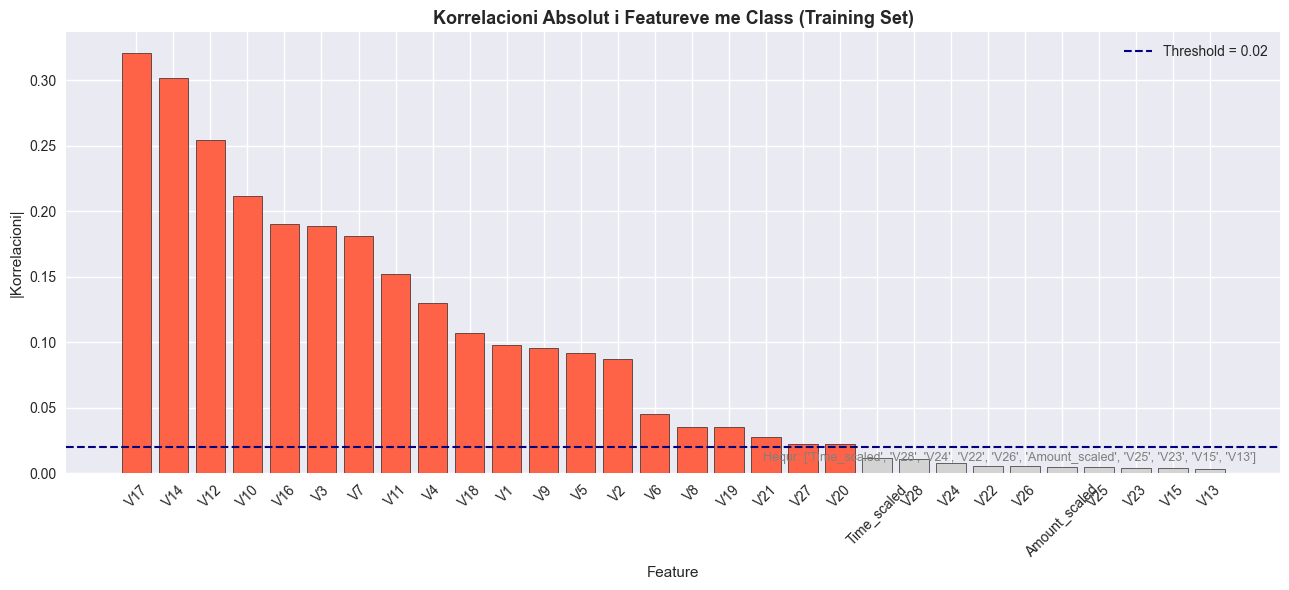

In [11]:
fig, ax = plt.subplots(figsize=(13, 6))

colors = ['tomato' if f in selected_features else 'lightgray' for f in corr_abs.index]
ax.bar(corr_abs.index, corr_abs.values, color=colors, edgecolor='black', linewidth=0.4)
ax.axhline(THRESHOLD, color='navy', linestyle='--', linewidth=1.5,
           label=f'Threshold = {THRESHOLD}')
ax.set_title('Korrelacioni Absolut i Featureve me Class (Training Set)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Feature')
ax.set_ylabel('|Korrelacioni|')
ax.tick_params(axis='x', rotation=45)
ax.legend()

if dropped_features:
    ax.text(0.98, 0.02, f'Hequr: {dropped_features}',
            transform=ax.transAxes, ha='right', va='bottom', fontsize=9, color='gray')

plt.tight_layout()
plt.savefig('../images/feature_selection.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# Aplikojme feature selection ne te gjitha set-et
sel_idx     = [feature_cols.index(f) for f in selected_features]

X_train_sel = X_train[:, sel_idx]
X_test_sel  = X_test[:, sel_idx]
X_all_sel   = df_scaled[selected_features].values  # per clustering (05)

print(f'Forma pas feature selection:')
print(f'  X_train : {X_train_sel.shape}')
print(f'  X_test  : {X_test_sel.shape}')
print(f'  X_all   : {X_all_sel.shape}  (per clustering)')
print(f'  y_train : {y_train.shape}    (SMOTE-balanced)')
print(f'  y_test  : {y_test.shape}')

Forma pas feature selection:
  X_train : (339903, 20)
  X_test  : (56746, 20)
  X_all   : (283726, 20)  (per clustering)
  y_train : (339903,)    (SMOTE-balanced)
  y_test  : (56746,)


## 6. Ruajtja e te Dhenave te Paraperpunuara

Ruajme te gjitha array-t numpy ne `data/processed/` per t'i ngarkuar ne notebook-et 03, 04, 05.

| File | Permbajtja | Perdoret nga |
|---|---|---|
| `X_train.npy` | Features trajnimi (SMOTE) | 03, 04 |
| `X_test.npy` | Features testimi | 03, 04 |
| `y_train.npy` | Labels trajnimi (SMOTE) | 03, 04 |
| `y_test.npy` | Labels testimi | 03, 04 |
| `X_all.npy` | Te gjitha features (skaluar) | 05 |
| `y_all.npy` | Te gjitha labels | 05 |
| `feature_names.npy` | Emrat e featureve | 03, 04, 05 |

In [13]:
PROCESSED_DIR = '../data/processed'
os.makedirs(PROCESSED_DIR, exist_ok=True)

np.save(f'{PROCESSED_DIR}/X_train.npy',       X_train_sel)
np.save(f'{PROCESSED_DIR}/X_test.npy',        X_test_sel)
np.save(f'{PROCESSED_DIR}/y_train.npy',       y_train)
np.save(f'{PROCESSED_DIR}/y_test.npy',        y_test)
np.save(f'{PROCESSED_DIR}/X_all.npy',         X_all_sel)
np.save(f'{PROCESSED_DIR}/y_all.npy',         df_scaled['Class'].values)
np.save(f'{PROCESSED_DIR}/feature_names.npy', np.array(selected_features))

print('=== RUAJTJA — SUKSES ===')
for fname in sorted(os.listdir(PROCESSED_DIR)):
    path = f'{PROCESSED_DIR}/{fname}'
    arr  = np.load(path, allow_pickle=True)
    size_kb = os.path.getsize(path) / 1024
    print(f'  {fname:<25} shape={str(arr.shape):<22} ({size_kb:.1f} KB)')

=== RUAJTJA — SUKSES ===
  X_all.npy                 shape=(283726, 20)           (44332.3 KB)
  X_test.npy                shape=(56746, 20)            (8866.7 KB)
  X_train.npy               shape=(339903, 20)           (53110.0 KB)
  feature_names.npy         shape=(20,)                  (0.4 KB)
  y_all.npy                 shape=(283726,)              (2216.7 KB)
  y_test.npy                shape=(56746,)               (443.5 KB)
  y_train.npy               shape=(339903,)              (2655.6 KB)


## 7. Permbledhja e Preprocessing

### Cfare beme:

| Hapi | Teknika | Arsyeja |
|---|---|---|
| Cleaning | `drop_duplicates()` | Eliminon data leakage nga rreshtat identike |
| Scaling | `StandardScaler` (Amount, Time) | V1-V28 jane PCA; Amount dhe Time duhen normalizuar |
| Split | 80/20 `stratified` | Ruan proporcionin e klasave ne te dyja set-et |
| SMOTE | `sampling_strategy=0.5` | Raporti 578:1 reduktohet ne 2:1 |
| Feature Selection | |r| >= 0.02 ndaj Class | Eliminon featurat jo-informative |

### Dataset-i final:
- **X_train** (SMOTE) + **X_test** + **y_train** + **y_test** — per modelet ne notebook 03 dhe 04
- **X_all** — per clustering pa label ne notebook 05

### Metrkat e rekomanduara:
> Accuracy nuk eshte metrika e duhur per fraud detection. Fokusi:
> - **Recall** — minimizojme False Negatives (fraud te pazbuluara)
> - **Precision** — minimizojme False Positives (alarme false)
> - **F1-score** — ekuilibri mes Recall dhe Precision
> - **ROC-AUC** — performanca e pergjithshme e diskriminimit